#Suspicious Activity Detection using NN

###Importing Libraries

In [ ]:
import cv2
import math

import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np

from keras.preprocessing import image
from keras.utils import np_utils
from keras.models import Sequential
from keras.applications.vgg16 import VGG16
from keras.applications.resnet import ResNet50
from keras.layers import Dense, InputLayer, Dropout, Conv2D, Flatten, LSTM
from keras.applications.vgg16 import preprocess_input as VGG_preprocess
from keras.applications.resnet import preprocess_input as resnet_preprocess

import tensorflow as tf
from skimage.transform import resize
from sklearn.model_selection import train_test_split

In [ ]:
# Testing GPU

%tensorflow_version 2.x
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


###Mounting Drive and uploading dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
# Path of dataset

dataset_path = "/content/drive/My Drive/Final_Year_Project/Cavier_Dataset/"
frames_path = "/content/drive/My Drive/Final_Year_Project/Cavier_Frames/"

In [ ]:
train = pd.read_csv(dataset_path + "Cavier_Train - Sheet1.csv")
test = pd.read_csv(dataset_path + "Cavier_Test - Sheet1.csv")

In [ ]:
train.head()

,Frame_Name,Suspicious
0,Fight_OneManDown220,1
1,Fight_OneManDown221,1
2,Fight_OneManDown222,1
3,Fight_OneManDown223,1
4,Fight_OneManDown224,1


In [ ]:
print("Total: ", len(train))
print("Suspicious: ", len(train[train['Suspicious'] == 1]))
print("Non-Suspicsious: ", len(train[train['Suspicious'] == 0]))

Total:  781
Suspicious:  413
Non-Suspicsious:  368


In [ ]:
test.head()

,Frame_Name,Suspicious
0,Fight_Chase300,1
1,Fight_Chase301,1
2,Fight_Chase302,1
3,Fight_Chase303,1
4,Fight_Chase304,1


In [ ]:
print("Total: ", len(test))
print("Suspicious: ", len(test[test['Suspicious'] == 1]))
print("Non-Suspicsious: ", len(test[test['Suspicious'] == 0]))

Total:  201
Suspicious:  101
Non-Suspicsious:  100


###Helper Functions

In [ ]:
# Function for reading the images

def read_image(dataset):
  X_p = []
  for image_name in dataset.Frame_Name:
    image = plt.imread(frames_path + image_name + '.jpg')
    X_p.append(image)

  X_p = np.array(X_p)

  return X_p

In [ ]:
# Resize the images for VGG16 and Resnet50

def resize1(X_p):
  image = []
  for i in range(len(X_p)):
    a = resize(X_p[i], preserve_range=True, output_shape=(224, 224)).astype(int)
    image.append(a)

  image = np.array(image)

  return image

In [ ]:
# Resize the images for IncpetionV3

def resize2(X_p):
  image = []
  for i in range(len(X_p)):
    a = resize(X_p[i], preserve_range=True, output_shape=(299, 299)).astype(int)
    image.append(a)

  image = np.array(image)

  return image

In [ ]:
def preprocess(X_p, model):
  if model == "VGG":
    X_p = VGG_preprocess(X_p)
  elif model == "Resnet":
    X_p = resnet_preprocess(X_p)

  return X_p

In [ ]:
def create_output(dataset):
  y = dataset.Suspicious
  y = np_utils.to_categorical(y)

  return y

In [ ]:
def declare_basemodel(model):
  if model == "VGG":
    return VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
  elif model == "Resnet":
    return ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

In [ ]:
def predict(model, X_p):
  if model == "VGG":
    X_p = VGG16base_model.predict(X_p)
  elif model == "Resnet":
    X_p = Resnetbase_model.predict(X_p)

  return X_p

In [ ]:
def reshape1(X_p):
  shape1 = X_p.shape[0]
  shape2 = X_p.shape[1] * X_p.shape[2] * X_p.shape[3]

  return X_p.reshape(shape1, shape2)

In [ ]:
def normalize(X_p):
  return X_p / X_p.max()

In [ ]:
def declare_NNModel(shape):
  model = Sequential()
  model.add(InputLayer((shape,)))
  model.add(Dense(units=1024, activation='relu'))
  model.add(Dropout(0.5))
  model.add(Dense(units=1024, activation='sigmoid'))
  model.add(Dropout(0.5))
  model.add(Dense(2, activation='softmax'))

  return model

In [ ]:
def declare_LSTM_Model(shape):
  model = Sequential()
  model.add(LSTM(1024,activation="relu",input_shape=(10,shape)))
  model.add(Dense(2, activation='softmax'))

  return model

###Utility Functions

In [ ]:
def shape(image):
  return image.shape

In [ ]:
def show(image):
  return plt.imshow(image)

###Main

In [ ]:
def preprocessing_train(model):
  X = None

  X = read_image(train)

  print("Shape of X: ", shape(X))

  print("Sample image:")
  show(X[0])

  X = resize1(X)

  print("Image after resizing:")
  show(X[0])

  if model == "VGG":
    X = preprocess(X, "VGG")
  else:
    X = preprocess(X, "Resnet")

  return X


In [ ]:
def preprocessing_test(model):
  X = None

  X = read_image(test)

  print("Shape of X: ", shape(X))

  print("Sample image:")
  show(X[0])

  X = resize1(X)

  print("Image after resizing:")
  show(X[0])

  if model == "VGG":
    X = preprocess(X, "VGG")
  else:
    X = preprocess(X, "Resnet")

  return X

In [ ]:
def accuracy(classes, dataset):
  result = dataset[['Suspicious']].to_numpy()
  result = result.transpose()
  count = 0
  for i in range(len(classes)):
    if result[0][i] == classes[i]:
      count += 1

  return count / len(classes)

###Preprocessing and training with VGG-16 as base model

Shape of X:  (781, 288, 384, 3)
Sample image:
Image after resizing:


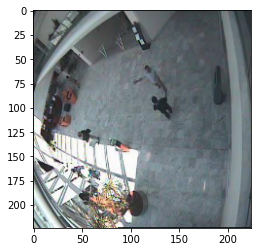

In [ ]:
XVGG = preprocessing_train("VGG")
y = create_output(train)

In [ ]:
XVGG_train, XVGG_valid, yVGG_train, yVGG_valid = train_test_split(XVGG, y, test_size=0.3, random_state=42)

In [ ]:
VGG16base_model = declare_basemodel("VGG")

58900480/58889256 [==============================] - 1s 0us/step


In [ ]:
XVGG_train = predict("VGG", XVGG_train)
XVGG_valid = predict("VGG", XVGG_valid)
print(shape(XVGG_train), shape(XVGG_valid))

(546, 7, 7, 512) (235, 7, 7, 512)


In [ ]:
XVGG_train = reshape1(XVGG_train)
XVGG_valid = reshape1(XVGG_valid)
print(shape(XVGG_train), shape(XVGG_valid))

(546, 25088) (235, 25088)


In [ ]:
XVGG_train = normalize(XVGG_train)
XVGG_valid = normalize(XVGG_valid)

In [ ]:
model1 = declare_NNModel(XVGG_train.shape[1])
model1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1024)              25691136  
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense_1 (Dense)             (None, 1024)              1049600   
                                                                 
 dropout_1 (Dropout)         (None, 1024)              0         
                                                                 
 dense_2 (Dense)             (None, 2)                 2050      
                                                                 
Total params: 26,742,786
Trainable params: 26,742,786
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
model1.fit(XVGG_train, yVGG_train, epochs=20, validation_data=(XVGG_valid, yVGG_valid))

Epoch 1/20
18/18 [==============================] - 1s 31ms/step - loss: 0.7310 - accuracy: 0.6264 - val_loss: 0.3353 - val_accuracy: 0.8213
Epoch 2/20
18/18 [==============================] - 0s 19ms/step - loss: 0.2329 - accuracy: 0.9029 - val_loss: 0.0826 - val_accuracy: 0.9957
Epoch 3/20
18/18 [==============================] - 0s 20ms/step - loss: 0.0557 - accuracy: 0.9835 - val_loss: 0.0086 - val_accuracy: 1.0000
Epoch 4/20
18/18 [==============================] - 0s 20ms/step - loss: 0.0117 - accuracy: 1.0000 - val_loss: 0.0020 - val_accuracy: 1.0000
Epoch 5/20
18/18 [==============================] - 0s 20ms/step - loss: 0.0051 - accuracy: 1.0000 - val_loss: 0.0025 - val_accuracy: 1.0000
Epoch 6/20
18/18 [==============================] - 0s 19ms/step - loss: 0.0033 - accuracy: 1.0000 - val_loss: 9.0339e-04 - val_accuracy: 1.0000
Epoch 7/20
18/18 [==============================] - 0s 20ms/step - loss: 0.0014 - accuracy: 1.0000 - val_loss: 6.8589e-04 - val_accuracy: 1.0000
Epoch

###Preprocessing and training with Resnet50 as base model

Shape of X:  (781, 288, 384, 3)
Sample image:
Image after resizing:


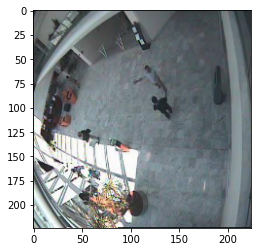

In [ ]:
XResnet = preprocessing_train("Resnet")
y = create_output(train)

In [ ]:
XResnet_train, XResnet_valid, yResnet_train, yResnet_valid = train_test_split(XResnet, y, test_size=0.3, random_state=42)

In [ ]:
Resnetbase_model = declare_basemodel("Resnet")

94781440/94765736 [==============================] - 1s 0us/step


In [ ]:
XResnet_train = predict("Resnet", XResnet_train)
XResnet_valid = predict("Resnet", XResnet_valid)
print(shape(XVGG_train), shape(XVGG_valid))

(546, 25088) (235, 25088)


In [ ]:
XResnet_train = reshape1(XResnet_train)
XResnet_valid = reshape1(XResnet_valid)
print(shape(XVGG_train), shape(XVGG_valid))

(546, 25088) (235, 25088)


In [ ]:
XResnet_train = normalize(XResnet_train)
XResnet_valid = normalize(XResnet_valid)

In [ ]:
model2 = declare_NNModel(XResnet_train.shape[1])
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 1024)              102761472 
                                                                 
 dropout_2 (Dropout)         (None, 1024)              0         
                                                                 
 dense_4 (Dense)             (None, 1024)              1049600   
                                                                 
 dropout_3 (Dropout)         (None, 1024)              0         
                                                                 
 dense_5 (Dense)             (None, 2)                 2050      
                                                                 
Total params: 103,813,122
Trainable params: 103,813,122
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
model2.fit(XResnet_train, yResnet_train, epochs=20, validation_data=(XResnet_valid, yResnet_valid))

Epoch 1/20
18/18 [==============================] - 2s 72ms/step - loss: 1.0239 - accuracy: 0.5861 - val_loss: 0.3137 - val_accuracy: 0.9872
Epoch 2/20
18/18 [==============================] - 1s 56ms/step - loss: 0.3198 - accuracy: 0.8608 - val_loss: 0.0354 - val_accuracy: 1.0000
Epoch 3/20
18/18 [==============================] - 1s 57ms/step - loss: 0.0508 - accuracy: 0.9872 - val_loss: 0.0026 - val_accuracy: 1.0000
Epoch 4/20
18/18 [==============================] - 1s 57ms/step - loss: 0.0096 - accuracy: 1.0000 - val_loss: 8.6230e-04 - val_accuracy: 1.0000
Epoch 5/20
18/18 [==============================] - 1s 55ms/step - loss: 0.0035 - accuracy: 1.0000 - val_loss: 6.0480e-04 - val_accuracy: 1.0000
Epoch 6/20
18/18 [==============================] - 1s 58ms/step - loss: 0.0035 - accuracy: 1.0000 - val_loss: 2.6278e-04 - val_accuracy: 1.0000
Epoch 7/20
18/18 [==============================] - 1s 56ms/step - loss: 0.0022 - accuracy: 1.0000 - val_loss: 2.5388e-04 - val_accuracy: 1.00

###Testing the model with VGG as base model

Shape of X:  (201, 288, 384, 3)
Sample image:
Image after resizing:


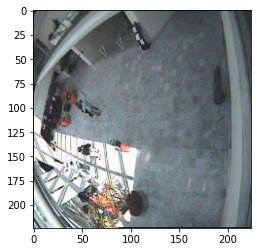

In [ ]:
testVGG = preprocessing_test("VGG")

In [ ]:
testVGG = predict("VGG", testVGG)
print(shape(testVGG))

(201, 7, 7, 512)


In [ ]:
testVGG = reshape1(testVGG)
print(shape(testVGG))

(201, 25088)


In [ ]:
testVGG = normalize(testVGG)

In [ ]:
predictVGG = model1.predict(testVGG)
print(len(predictVGG))

201


In [ ]:
classesVGG = np.argmax(predictVGG, axis=1)

In [ ]:
print("----Accuracy----")
print(accuracy(classesVGG, test))

----Accuracy----
0.6069651741293532


###Testing the model with Resnet50 as base model

Shape of X:  (201, 288, 384, 3)
Sample image:
Image after resizing:


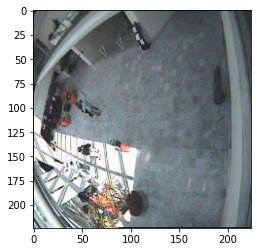

In [ ]:
testResnet = preprocessing_test("Resnet")

In [ ]:
testResnet = predict("Resnet", testResnet)
print(shape(testResnet))

(201, 7, 7, 2048)


In [ ]:
testResnet = reshape1(testResnet)
print(shape(testResnet))

(201, 100352)


In [ ]:
testResnet = normalize(testResnet)

In [ ]:
predictResnet = model2.predict(testResnet)
print(len(predictResnet))

201


In [ ]:
classesResnet = np.argmax(predictResnet, axis=1)

In [ ]:
print("----Accuracy----")
print(accuracy(classesResnet, test))


----Accuracy----
0.8455223880597015


###RNN

In [ ]:
temp=XResnet_train[0:540].reshape((54,10,XResnet_train.shape[1]))

In [ ]:
temp_y=yResnet_train[9:546:10]

In [ ]:
temp_valid=XResnet_valid[0:230].reshape((23,10,XResnet_valid.shape[1]))
temp_y_valid=yResnet_valid[9:230:10]

In [ ]:
model4=Sequential()

In [ ]:
for layer in model2.layers[:-1]:
  model4.add(layer)

In [ ]:
model4.build((None,XResnet_train.shape[1]))

In [ ]:
model4.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 1024)              102761472 
                                                                 
 dropout_2 (Dropout)         (None, 1024)              0         
                                                                 
 dense_4 (Dense)             (None, 1024)              1049600   
                                                                 
 dropout_3 (Dropout)         (None, 1024)              0         
                                                                 
Total params: 103,811,072
Trainable params: 103,811,072
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model4.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
result = model4.predict(XResnet_train)

In [ ]:
result_valid = model4.predict(XResnet_valid)

In [ ]:
result_valid.shape

(235, 1024)

In [ ]:
def lstm_layer():
  model = Sequential()
  model.add(LSTM(1024,activation="relu",batch_input_shape=(None,10,1024)))
  model.add(Dense(2, activation='softmax'))
  return model

In [ ]:
lstm = lstm_layer()

In [ ]:
lstm.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 1024)              8392704   
                                                                 
 dense_6 (Dense)             (None, 2)                 2050      
                                                                 
Total params: 8,394,754
Trainable params: 8,394,754
Non-trainable params: 0
_________________________________________________________________


In [ ]:
reshaped_result=result[0:540].reshape((54,10,result.shape[1]))
result_y=yResnet_train[9:546:10]

In [ ]:
reshaped_result_valid=result_valid[0:230].reshape((23,10,result.shape[1]))
result_y_vaid=yResnet_train[9:235:10]

In [ ]:
result_y_valid=result_y_vaid
print(result_y_vaid.shape)

(23, 2)


In [ ]:
lstm.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
lstm.fit(reshaped_result, result_y, epochs=20, validation_data=(reshaped_result_valid, result_y_valid))

Epoch 1/20
2/2 [==============================] - 2s 394ms/step - loss: 7.0185 - accuracy: 0.5185 - val_loss: 1.0376 - val_accuracy: 0.7826
Epoch 2/20
2/2 [==============================] - 0s 95ms/step - loss: 1.3856 - accuracy: 0.5185 - val_loss: 1.0455 - val_accuracy: 0.3478
Epoch 3/20
2/2 [==============================] - 0s 100ms/step - loss: 0.4038 - accuracy: 0.8148 - val_loss: 0.7633 - val_accuracy: 0.7826
Epoch 4/20
2/2 [==============================] - 0s 98ms/step - loss: 0.2897 - accuracy: 0.8333 - val_loss: 1.3486 - val_accuracy: 0.4348
Epoch 5/20
2/2 [==============================] - 0s 103ms/step - loss: 0.0820 - accuracy: 1.0000 - val_loss: 2.5341 - val_accuracy: 0.4348
Epoch 6/20
2/2 [==============================] - 0s 98ms/step - loss: 0.0210 - accuracy: 1.0000 - val_loss: 3.1922 - val_accuracy: 0.4348
Epoch 7/20
2/2 [==============================] - 0s 95ms/step - loss: 0.0042 - accuracy: 1.0000 - val_loss: 4.7371 - val_accuracy: 0.4348
Epoch 8/20
2/2 [========

In [ ]:
result_test = model4.predict(testResnet)

In [ ]:
reshaped_result_test=result_test[0:200].reshape((20,10,result_test.shape[1]))

In [ ]:
reshaped_result_test.shape

(20, 10, 1024)

In [ ]:
result_y_test = lstm.predict(reshaped_result_test)

In [ ]:
classesLstm = np.argmax(result_y_test, axis=1)

In [ ]:
classesLstm

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])